/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_90360/110825197.py:84: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle((i - box_width/2, q1), box_width, height, color='lightgreen', edgecolor='black')


10-15 paired with 21-26: n = 130
11-16 paired with 22-27: n = 22
12-17 paired with 23-28: n = 39
14-19 paired with 25-30: n = 69
15-20 paired with 26-31: n = 47
16-21 paired with 27-32: n = 30
17-22 paired with 28-33: n = 28
18-23 paired with 29-34: n = 49
20-25 paired with 31-36: n = 101
21-26 paired with 32-37: n = 131
22-27 paired with 33-38: n = 63
23-28 paired with 34-39: n = 48
24-29 paired with 35-40: n = 75


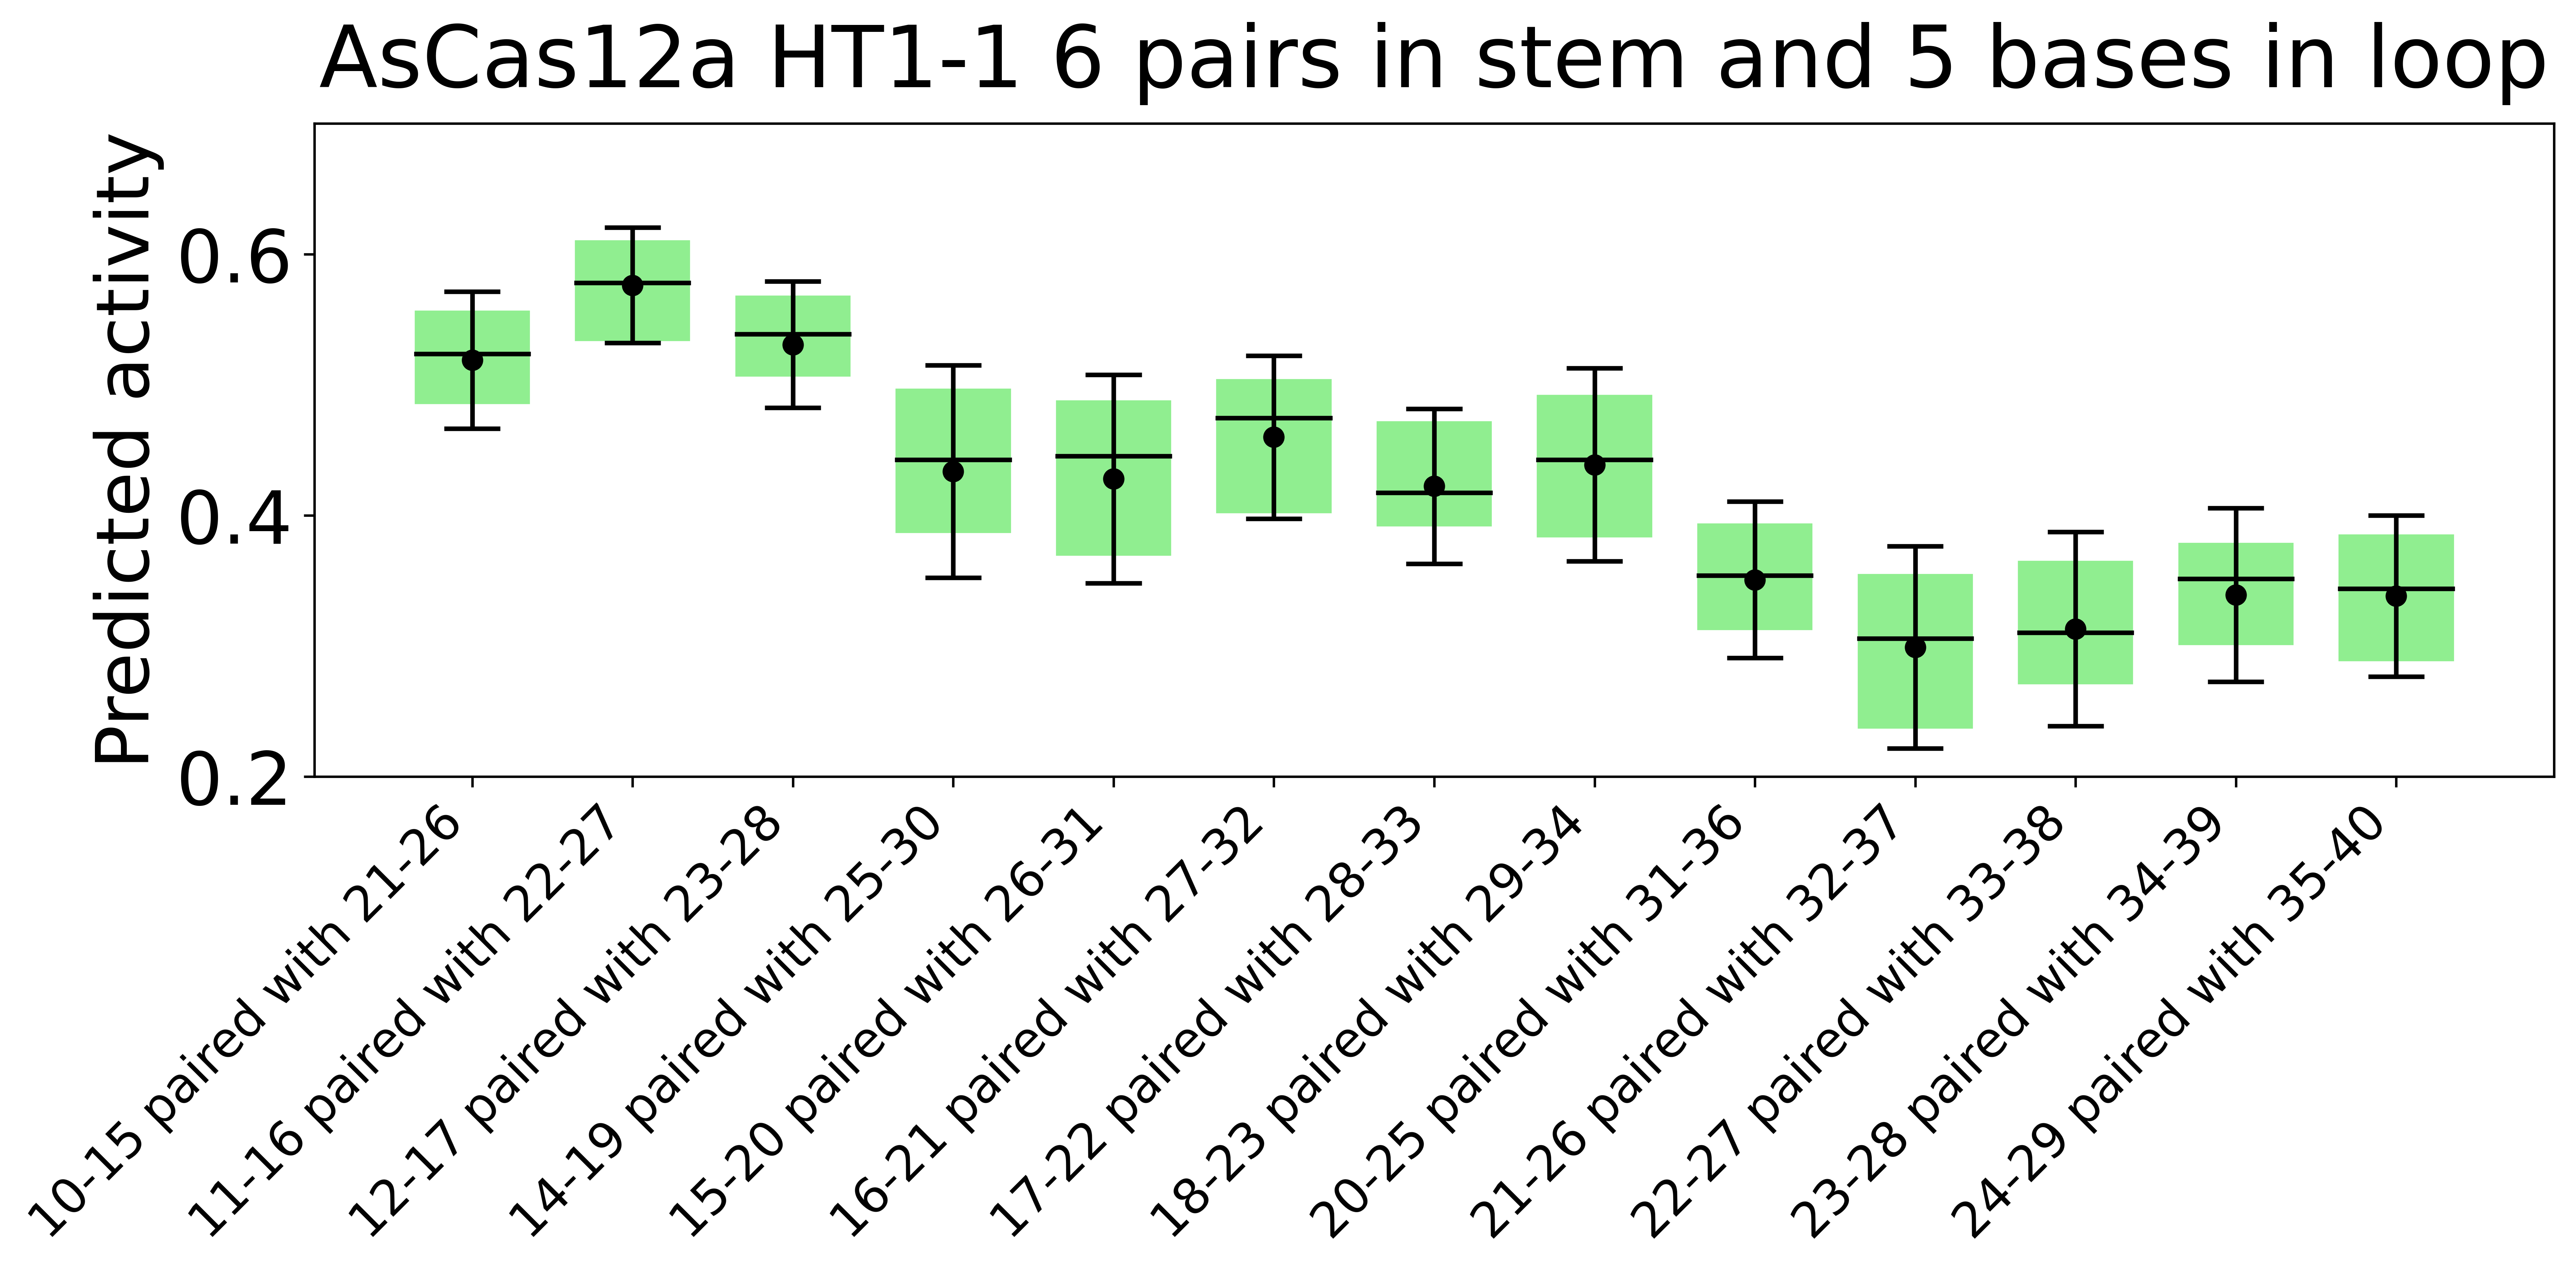

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# === Update font sizes globally ===
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 24,
    'legend.fontsize': 14
})

sample_counts = []

# Directory containing your text files
folder = '.'  # Adjust if needed

def numeric_key(filename):
    label = filename.replace("test_generated_random_dna_6_pairs_", "").replace("_preds_HT11.txt", "")
    nums = [int(n) for n in label.replace("paired_with", "").split("_") if n.isdigit()]
    return nums  # will sort based on all numbers

file_list = sorted([
    f for f in os.listdir(folder)
    if f.startswith("test_generated_random_dna_6_pairs_") and f.endswith("_preds_HT11.txt")
], key=numeric_key)

x_labels, q1_values, q3_values = [], [], []
medians, means, stds = [], [], []

def extract_label(filename):
    # Remove prefix and suffix
    core = filename.replace("test_generated_random_dna_6_pairs_", "")
    core = core.replace("_preds_HT11.txt", "")
    return core

def format_label(label):
    parts = label.split('_')
    return f"{parts[0]}-{parts[1]} paired with {parts[4]}-{parts[5]}"



# Collect stats
for filename in file_list:
    with open(os.path.join(folder, filename), 'r') as f:
        values = [float(line.strip()) for line in f if line.strip()]
    if not values:
        continue
    values = np.array(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    median = np.median(values)
    mean = np.mean(values)
    std = np.std(values)

    x_labels.append(extract_label(filename))
    q1_values.append(q1)
    q3_values.append(q3)
    medians.append(median)
    means.append(mean)
    stds.append(std)
    sample_counts.append(len(values))

# Plot
x = np.arange(len(x_labels))
fig, ax = plt.subplots(figsize=(max(12, len(x_labels) * 0.6), 6), dpi=600)
ax.set_title(
    "AsCas12a HT1-1 6 pairs in stem and 5 bases in loop",
    fontsize=28,
    pad=12
)

box_width = 0.7
error_bar_width = box_width * 0.5  # Match width of IQR boxes

# Remove grid
ax.grid(False)

# Draw IQR boxes
for i, (q1, q3) in enumerate(zip(q1_values, q3_values)):
    height = q3 - q1
    rect = patches.Rectangle((i - box_width/2, q1), box_width, height, color='lightgreen', edgecolor='black')
    ax.add_patch(rect)

# Draw median lines
for i, med in enumerate(medians):
    ax.plot([i - box_width/2, i + box_width/2], [med, med], color='black', linewidth=1.5)

# Draw custom mean ± SD error bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax.plot([i], [m], marker='o', color='black')  # Mean point
    ax.vlines(i, m - s, m + s, color='black', linewidth=1.5)
    ax.hlines([m - s, m + s], i - error_bar_width/2, i + error_bar_width/2, color='black', linewidth=1.5)

for lbl, n in zip(x_labels, sample_counts):
    print(f"{format_label(lbl)}: n = {n}")


# Axis styling
ax.set_xticks(x)
formatted_labels = [format_label(lbl) for lbl in x_labels]
ax.set_xticklabels(formatted_labels, rotation=45, ha='right')
ax.set_ylabel("Predicted activity")
ax.set_ylim(0.2, 0.7)
plt.tight_layout()
plt.show()


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_90360/2065707674.py:86: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle((i - box_width/2, q1), box_width, height, color='lightgreen', edgecolor='black')


9-15 paired with 20-26: n = 77
10-16 paired with 21-27: n = 121
11-17 paired with 22-28: n = 62
12-18 paired with 23-29: n = 72
13-19 paired with 24-30: n = 31
14-20 paired with 25-31: n = 66
15-21 paired with 26-32: n = 67
16-22 paired with 27-33: n = 46
17-23 paired with 28-34: n = 85
18-24 paired with 29-35: n = 50
20-26 paired with 31-37: n = 83
21-27 paired with 32-38: n = 131
22-28 paired with 33-39: n = 80
23-29 paired with 34-40: n = 76


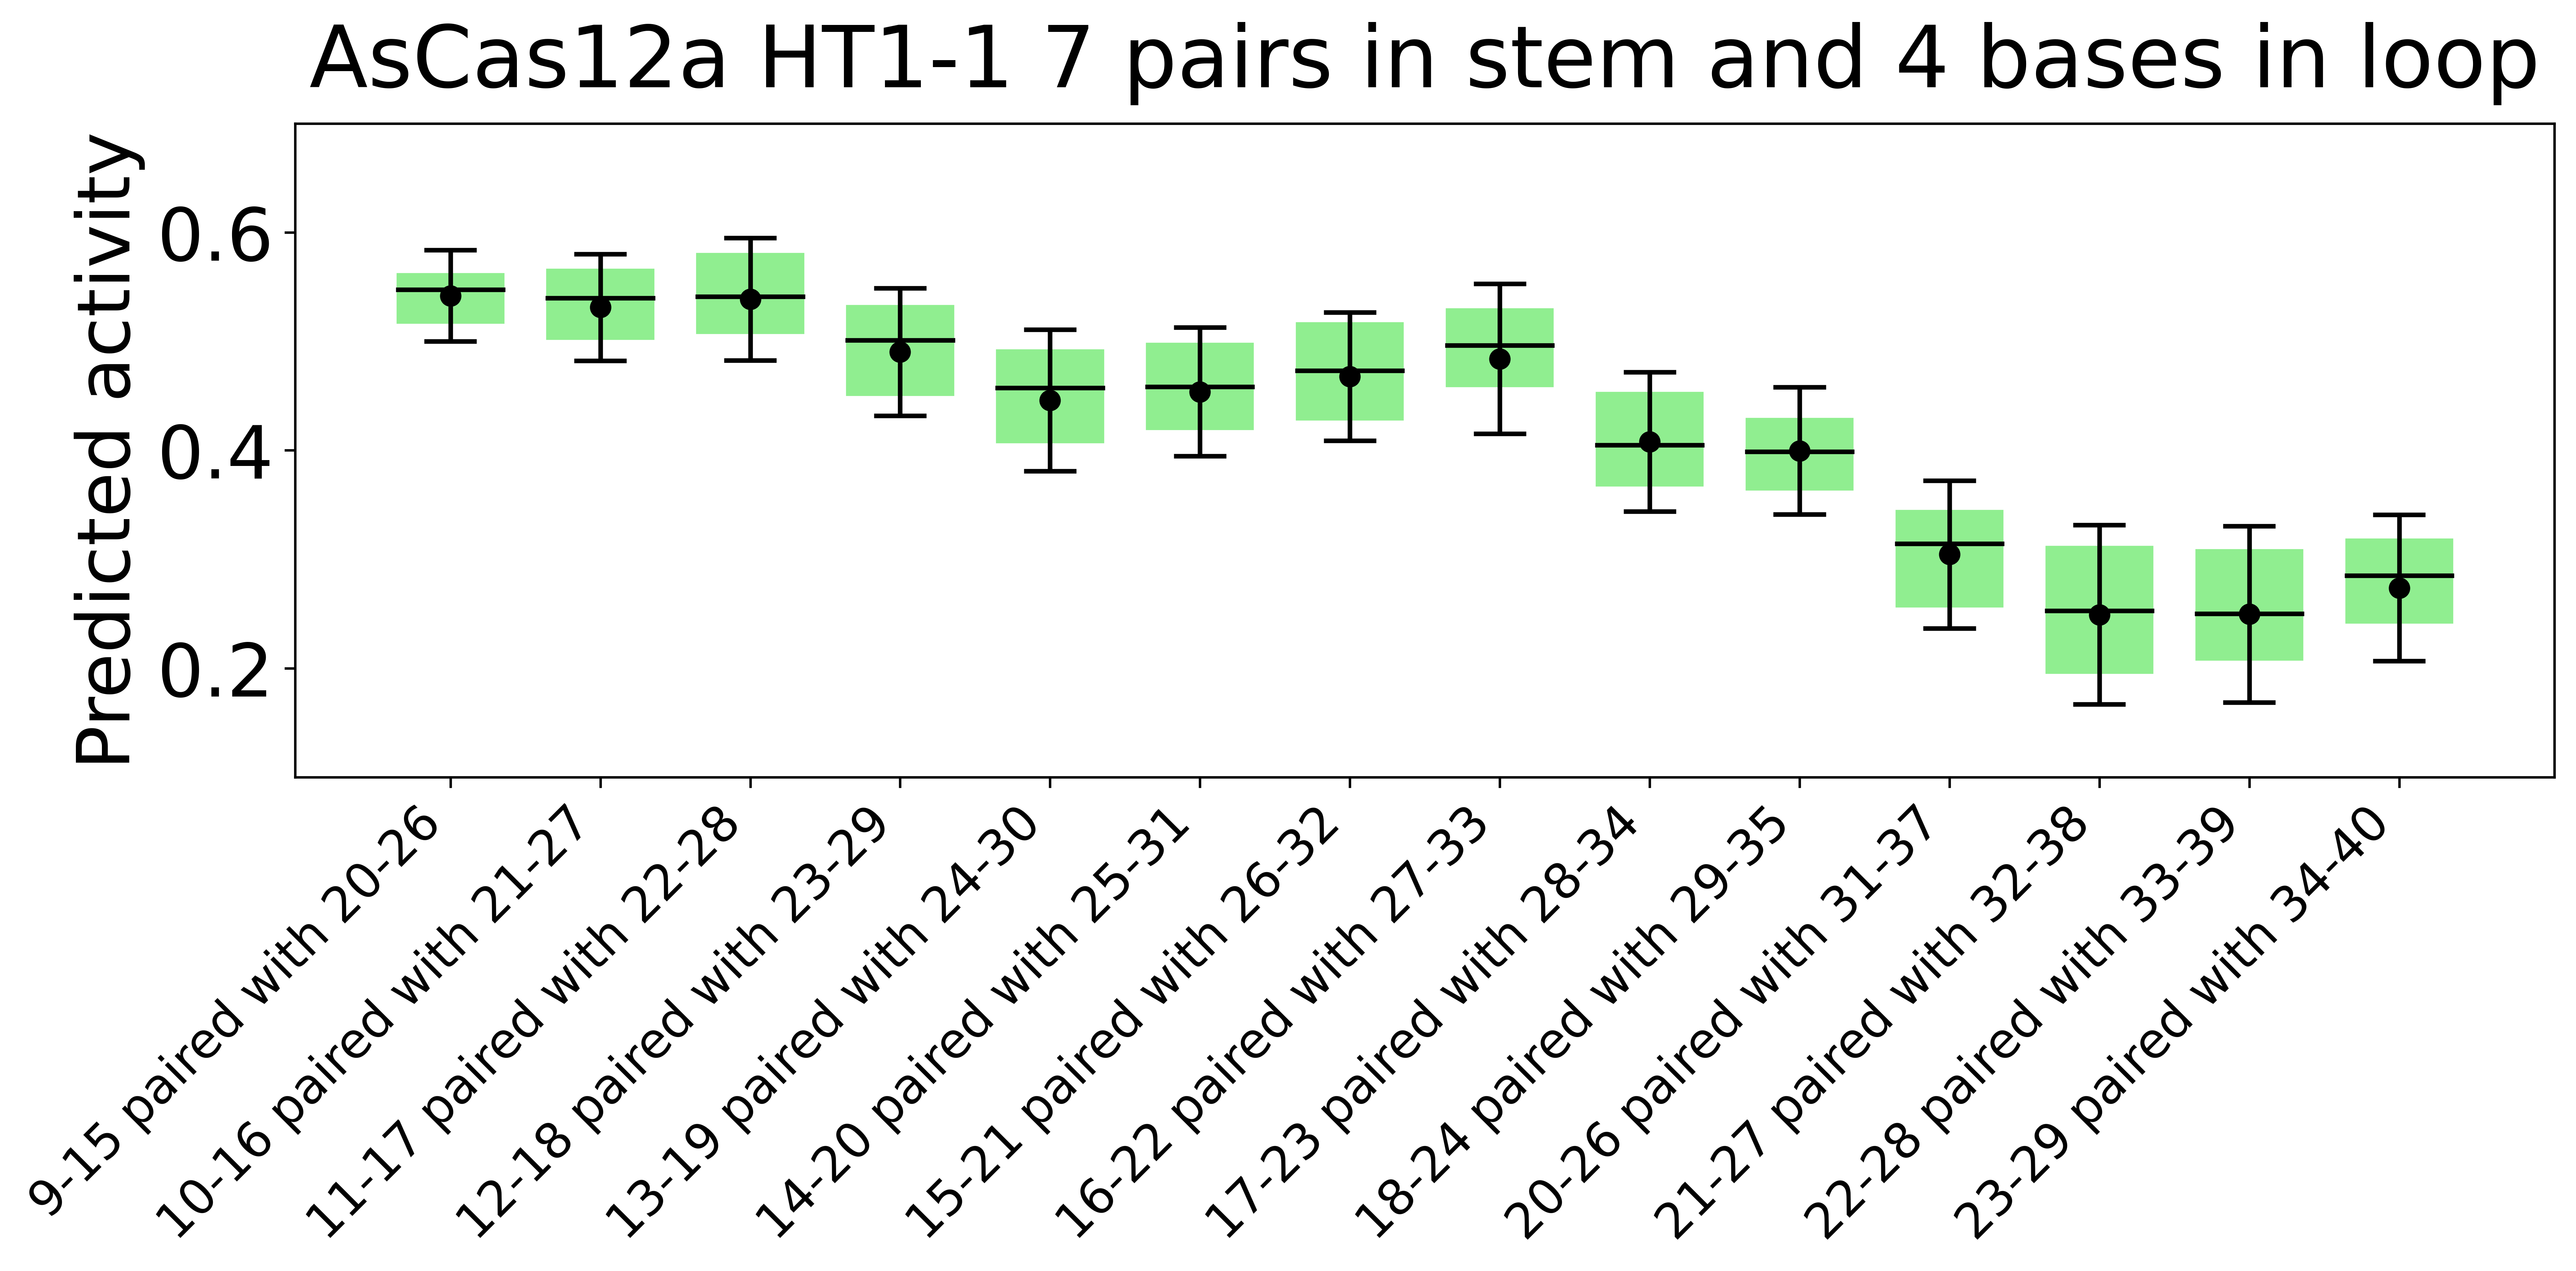

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# === Update font sizes globally ===
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 24,
    'legend.fontsize': 14
})

sample_counts = []


# Directory containing your text files
folder = '.'  # Adjust if needed

def numeric_key(filename):
    label = filename.replace("test_generated_random_dna_7_pairs_", "").replace("_preds_HT11.txt", "")
    nums = [int(n) for n in label.replace("paired_with", "").split("_") if n.isdigit()]
    return nums  # will sort based on all numbers

file_list = sorted([
    f for f in os.listdir(folder)
    if f.startswith("test_generated_random_dna_7_pairs_") and f.endswith("_preds_HT11.txt")
], key=numeric_key)

x_labels, q1_values, q3_values = [], [], []
medians, means, stds = [], [], []

def extract_label(filename):
    # Remove prefix and suffix
    core = filename.replace("test_generated_random_dna_7_pairs_", "")
    core = core.replace("_preds_HT11.txt", "")
    return core

def format_label(label):
    parts = label.split('_')
    return f"{parts[0]}-{parts[1]} paired with {parts[4]}-{parts[5]}"



# Collect stats
for filename in file_list:
    with open(os.path.join(folder, filename), 'r') as f:
        values = [float(line.strip()) for line in f if line.strip()]
    if not values:
        continue
    values = np.array(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    median = np.median(values)
    mean = np.mean(values)
    std = np.std(values)

    x_labels.append(extract_label(filename))
    q1_values.append(q1)
    q3_values.append(q3)
    medians.append(median)
    means.append(mean)
    stds.append(std)
    sample_counts.append(len(values))


# Plot
x = np.arange(len(x_labels))
fig, ax = plt.subplots(figsize=(max(12, len(x_labels) * 0.6), 6), dpi=600)
ax.set_title(
    "AsCas12a HT1-1 7 pairs in stem and 4 bases in loop",
    fontsize=28,
    pad=12
)

box_width = 0.7
error_bar_width = box_width * 0.5  # Match width of IQR boxes

# Remove grid
ax.grid(False)

# Draw IQR boxes
for i, (q1, q3) in enumerate(zip(q1_values, q3_values)):
    height = q3 - q1
    rect = patches.Rectangle((i - box_width/2, q1), box_width, height, color='lightgreen', edgecolor='black')
    ax.add_patch(rect)

# Draw median lines
for i, med in enumerate(medians):
    ax.plot([i - box_width/2, i + box_width/2], [med, med], color='black', linewidth=1.5)

# Draw custom mean ± SD error bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax.plot([i], [m], marker='o', color='black')  # Mean point
    ax.vlines(i, m - s, m + s, color='black', linewidth=1.5)
    ax.hlines([m - s, m + s], i - error_bar_width/2, i + error_bar_width/2, color='black', linewidth=1.5)

for lbl, n in zip(x_labels, sample_counts):
    print(f"{format_label(lbl)}: n = {n}")

# Axis styling
ax.set_xticks(x)
formatted_labels = [format_label(lbl) for lbl in x_labels]
ax.set_xticklabels(formatted_labels, rotation=45, ha='right')
ax.set_ylabel("Predicted activity")
ax.set_ylim(0.1, 0.7)
plt.tight_layout()
plt.show()
